In [2]:
import numpy as np
import matplotlib.pyplot as plt

## **Part (a): Dimensionless equation of motion**

The equation of motion is as follows:
$$m\ddot{x} = -\frac{dV}{dx} \\[10 pt]
\implies m\ddot{x} = -m \omega^2 x - 3 \lambda x^2 \tag{a.1}$$

We have the following variables:
$$x_0 = -\frac{m\omega^2}{3\lambda} \tag{a.2}$$
$$\xi = \frac{x}{|x_0|} \implies x = |x_0| \xi \tag{a.3}$$
$$\tau = \omega t \implies t = \frac{\tau}{\omega} \implies \frac{d}{dt} = \omega\frac{d}{d\tau} \tag{a.4}$$

From the above expressions, we calculate:
$$\dot{x} = \frac{d}{dt}(|x_0| \xi) = |x_0| \omega\frac{d\xi}{d\tau} = \omega |x_0| \xi' \tag{a.5}$$
$$\ddot{x} = \frac{d}{dt}(\omega |x_0| \xi') = \omega |x_0| (\omega \frac{d\xi'}{d\tau}) = \omega^2|x_0|\xi'' \tag{a.6}$$

**Part (i):**

Substituting these into (a.1):
$$m\omega^2|x_0|\xi'' = -m\omega^2(|x_0|\xi) - 3\lambda (|x_0| \xi)^2 \\[10 pt]
\implies \xi'' = -\xi - \frac{3\lambda}{m\omega^2}|x_0|\xi^2 \\[10 pt]
\implies \xi'' = -\xi + \xi^2 \tag{a.7}$$

To derive the equation, we used:
$$|x_0| = x_0 = -\frac{m\omega^2}{3\lambda} \tag{a.8}$$
Hence, $x_0 > 0 \implies \lambda < 0$.

**Part (ii):**
$$
V(x) = \frac{1}{2}m\omega^2x^2 + \lambda x^3 \\[10 pt]
\implies V(\xi) = \frac{1}{2}m\omega^2 |x_0|^2\xi^2 + \lambda |x_0|^3\xi^3 = m \omega^2|x_0|^2 \left(\frac{1}{2}\xi^2 + \frac{\lambda|x_0|}{m \omega^2} \xi^3\right)\\[10 pt]
\implies V(\xi) = m \omega^2|x_0|^2 \left(\frac{1}{2}\xi^2 -\frac{1}{3}\xi^3\right)
$$
(using (a.8))

Dividing by $m\omega^2|x_0|^2$(dimensions of energy), we get:
$$\nu(\xi) = \frac{V(\xi)}{m\omega^2|x_0|^2} = \frac{1}{2}\xi^2 -\frac{1}{3}\xi^3 \tag{a.9}$$

The total energy:
$$E = \frac{1}{2}m\dot{x}^2 + V(x) = m(\omega|x_0|\xi')^2 + V(\xi) \\
\implies E = m\omega^2|x_0|^2\left(\frac{1}{2}(\xi')^2 + \nu(\xi)\right)$$

Dividing by $m\omega^2|x_0|^2$(dimensions of energy), we get:
$$\varepsilon = \frac{E}{m\omega^2|x_0|^2} = \frac{1}{2}(\xi')^2 + \nu(\xi) \tag{a.10}$$

The barrier is present at:
$$\frac{d\nu}{d\xi} = 0 \\
\implies \xi - \xi^2 = 0 \\
\implies \xi = 0, 1$$

For maximum:
$$\frac{d^2\nu}{d\xi^2} < 0 \\
\implies \xi > \frac{1}{2}$$

Thus, the barrier is present at $\xi = 1$
$$\nu(1) = \frac{1}{2} - \frac{1}{3} = \frac{1}{6}$$

Escape requires $\varepsilon \ge \nu(1) \implies \varepsilon \ge \frac{1}{6}$

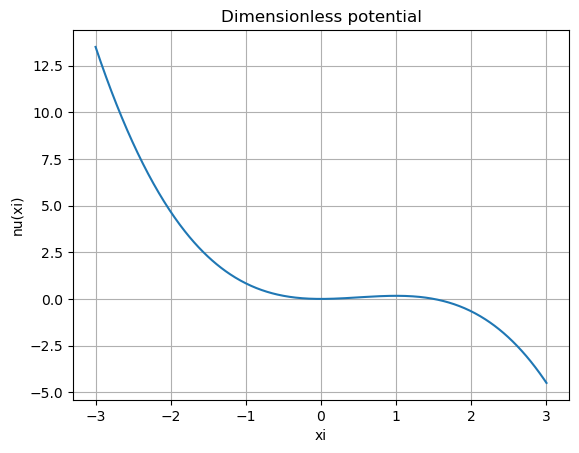

In [3]:
# Plotting nu(xi) - dimensionless potential
def nu(xi):
    return 1/2*xi**2 - 1/3*xi**3

xii, xif = -3, 3
dxi = 1e-2
N = int((xif-xii)/dxi)+1
xis = np.linspace(xii, xif, N)
nus = nu(xis)

plt.plot(xis, nus)
plt.xlabel("xi")
plt.ylabel("nu(xi)")
plt.title("Dimensionless potential")
plt.grid()
plt.show()

## **Part (b): Period of small oscillations**

**Part (i):**

In [4]:
def w_eff(A):
    return 1 - 5*A**2/12

w_eff(0.3)

0.9625

**Part (ii):**

For simple harmonic case:
$$\nu_h = \frac{1}{2}\xi^2$$

The cubic term $-\frac{1}{3}\xi^3$ has the following effect:

$\xi > 0$:
$$-\frac{1}{3}\xi^3 < 0 \implies \nu < \nu_h$$
The potential flattens out $\rightarrow$ weaker restoring force.

$\xi < 0:$
$$-\frac{1}{3}\xi^3 > 0 \implies \nu > \nu_h$$
The potential becomes steeper $\rightarrow$ stronger restoring force.

Since the potential is asymmetric, the particle does not spend the same amount of time in both the regions. It spends more time on the flatter side $(\xi > 0)$ than on the steeper side $(\xi < 0)$. Since $\omega$ depends on the total period of oscillation, the effect of the flatter region dominates, hence frequency decreases compared to the purely harmonic case.

## **Part (c): RK4 Implementation**

We consider the following:

$\xi = y[0] \\[10 pt]
\xi' = y[1]$

In [ ]:
# RK4
def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# Dimensionless potential
def dim_V(y):
    return 1/2*y[0]**2 - 1/3*y[0]**3

# Total energy
def tot_energy(y):
    return 1/2*y[1]**2 + dim_V(y)

# Caller for RK4 method
def caller1(fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    Es = np.zeros(N)
    
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        Es[i] = tot_energy(y)
        y = rk4(fn, x, y, h)
     
    return ys, Es

# d/dt[e e']
def f(t, y):
    return np.asarray([y[1], -y[0]+y[0]**2])


**Case A and Case B:**

In [ ]:
# Time grid
ti, tf = 0, 50
dt = 1e-2
N = int((tf-ti)/dt) + 1
ts1 = np.linspace(ti, tf, N)

# Initial conditions
Y01 = np.array([0.3, 0.0])
Y02 = np.array([0.9, 0.0])

# Implementing RK4
Ys1, Es1 = caller1(f, Y01, N, ts1, dt)
Ys2, Es2 = caller1(f, Y02, N, ts1, dt)

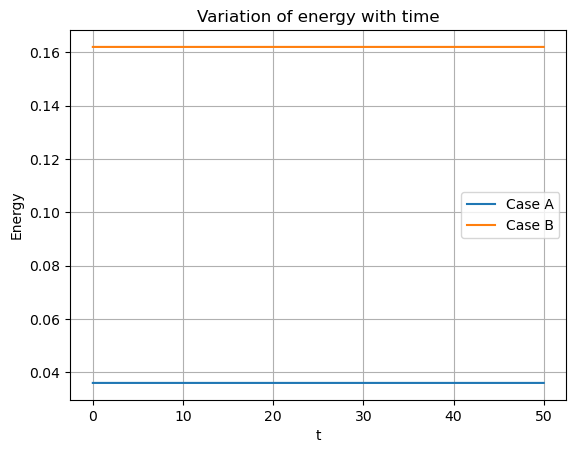

In [7]:
# Energy conservation
plt.plot(ts1, Es1, label="Case A")
plt.plot(ts1, Es2, label="Case B")

plt.xlabel("t")
plt.ylabel("Energy")
plt.title("Variation of energy with time")

plt.legend()
plt.grid()
plt.show()

**Case C:**

*Initial conditions:*
$$(\xi, \xi') = (0.3, 0.6)$$

*Total energy:*
$$\varepsilon(0.3, 0.6) = 0.216$$

*Barrier height:*
$$\nu(1) = 1/6 \approx 0.167$$

Hence, the particle crosses the barrier and rolls down the potential as soon as $\xi > 1$. After crossing the barrier and covering large distance:
$$\xi'' = -\xi + \xi^2 \approx \xi^2$$
since $\xi^2$ term dominates. Hence, acceleration becomes very large $\rightarrow$ overflow occurs.

Hence, we are asked to stop at $\xi > 5$ because after that overflow occurs.

In [45]:
print(nu(1))
print(tot_energy([0.3, 0.6]))

0.16666666666666669
0.216


In [41]:
# Time grid
ti, tf = 0, 50
dt = 1e-2
N = int((tf-ti)/dt) + 1
ts2 = np.linspace(ti, tf, N)

# Caller for RK4 method
def caller2(fn, y_ini, N, xs, h):
	y = y_ini
	ys = np.zeros((N, len(y_ini)), dtype=np.float64)
	Es = np.zeros(N)
	i = 0

	# Stopping at xi = 0.5
	# for i in range(N):
	while y[0] <= 5:
		x = xs[i]
		ys[i, :] = y
		Es[i] = tot_energy(y)
		y = rk4(fn, x, y, h)
		i += 1

	# print(i)
	ys, Es = ys[:i], Es[:i]
	return ys, Es

# Implementing RK4
Y03 = np.array([0.3, 0.6])
# Nt = 510
Ys3, Es3 = caller2(f, Y03, N, ts2, dt)

## **Part (d): Plots**

**Part (i): Phase portrait**

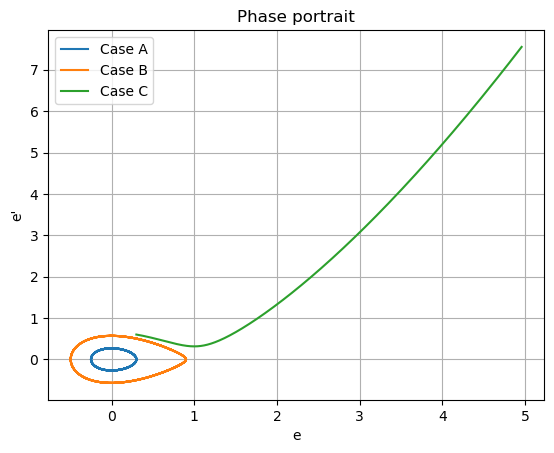

In [42]:
plt.plot(Ys1[:, 0], Ys1[:, 1], label = "Case A")
plt.plot(Ys2[:, 0], Ys2[:, 1], label = "Case B")
plt.plot(Ys3[:, 0], Ys3[:, 1], label = "Case C")

plt.xlabel("e")
plt.ylabel("e'")
plt.title("Phase portrait")

plt.legend()
plt.grid()
plt.show()

**Part (ii): Energy drift**

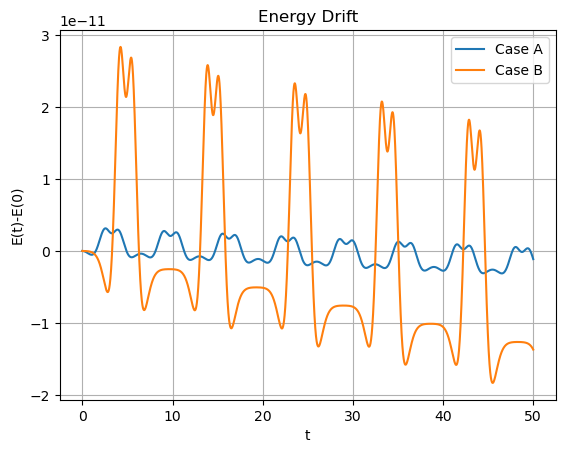

In [43]:
plt.plot(ts1, Es1 - tot_energy(Y01), label = "Case A")
plt.plot(ts1, Es2 - tot_energy(Y02), label = "Case B")

plt.xlabel("t")
plt.ylabel("E(t)-E(0)")
plt.title("Energy Drift")

plt.legend()
plt.grid()
plt.show()

**Part (iii): Escape**

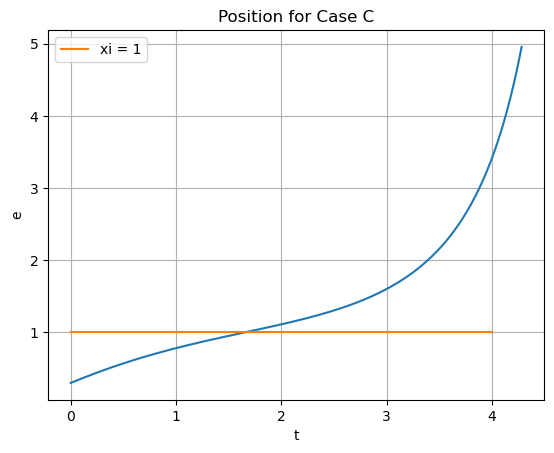

In [46]:
plt.plot(ts2[:len(Es3)], Ys3[:, 0])
plt.plot([0, 4], [1, 1], label = f"xi = 1")

plt.xlabel("t")
plt.ylabel("e")
plt.title("Position for Case C")

plt.legend()
plt.grid()
plt.show()